# НИР - Анализ размера заработной платы для разных специальностей в зависимости от различных факторов на основе датасета Job Dataset

### Цель работы

Исследовать  базу  данных  и  изучить  данные  о  вакансиях  и  размере 
заработной  платы,  выявить  закономерность  различными  факторами  и 
размером заработной платы.  Это позволит соискателям  находить вакансии, 
которые будут наиболее подходить им по условиям труда и размерам оплаты 
труда.

### Задачи

1.  Определение данных. 
2.  Формулирование гипотез. 
3.  Загрузка данных в Python. 
4.  Проверка данных. 
5.  Очистка данных. 
6.  Преобразование данных. 
7.  Выбор данных для анализа. 
8.  Агрегирование данных. 
9.  Визуализация данных. 
10.  Подтверждение или опровержение поставленных гипотез. 
11.  Корреляционный анализ. 
12.  Формулирование ограничений и выводов.

### Определение данных для анализа

Для  анализа  был  выбран  DataSet  «Job  Dataset».  Этот  набор  данных представляет  собой  полную  коллекцию синтетических объявлений о вакансиях для облегчения исследований и анализа в области тенденций рынка труда. 

Таблица имеет 1615940 записей. Каждая запись содержит информацию о  названии должности, описание вакансии, обязанности, требуемый опыт и квалификацию,  местоположение,  включая  страну,  широту  и  долготу,  тип работы, вилку заработной платы, предпочтения к соискателю, обязанности и прочее.

### Формулирование гипотез 

1.  Опыт  работы  больше  влияет  на  уровень  зарплаты,  чем  уровень образования. 
2. Вакансии,  требующие  узкоспециализированных  технических навыков,  предлагают  более  высокую  зарплату,  но  при  добавлении управленческих навыков относительная премия снижается. 
3.  В больших компаниях на аналогичных позициях платят в среднем больше, чем в малых. 
4. Зарплатные  предложения  имеют  сезонную  зависимость  от  даты размещения вакансии, при этом пик зарплат приходится на начало года. 
 
### Обоснование сформулированных гипотез 

1.  Выдвинуто предположение, что требуемый опыт работы имеет более сильную корреляцию с верхней границей зарплатного диапазона, чем уровень образования. 
2.  Выдвинуто  предположение,  что  чем  уже  и  сложнее  технический навык требуется для работы, тем выше зарплата. Но если к такому узкому  навыку  добавляют  требования  к  коммуникации  или 
управлению людьми, то зарплата растет уже не так сильно.  
3.  Считается,  что  в  крупных  компаниях  уровень  зарплаты  в  среднем выше, чем в малых и средних. 
4.  Поскольку  в  новом  году  начинается  и  новый  период  ведения бухгалтерии,  то  логично  предположить,  что  новые  вакансии появляются  в  начале  года  чаще,  а  соответственно  и  предлагают соискателям больше.

### Подготовка данных для работы 

Для  анализа  данных  было  использовано  программное  обеспечение «Pandas» совместно с «matplotlib».

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Для загрузки csv  файла с данными в pandas  была использована функция read_csv().

In [5]:
PATH_TO_CSV = "./job_descriptions.csv"
data = pd.read_csv(PATH_TO_CSV)

### Проверка данных 
Набор данных был проверен на наличие данных по столбцам. Для этого был использован метод info() для объектов dataframe.

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1615940 entries, 0 to 1615939
Data columns (total 23 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Job Id            1615940 non-null  int64  
 1   Experience        1615940 non-null  str    
 2   Qualifications    1615940 non-null  str    
 3   Salary Range      1615940 non-null  str    
 4   location          1615940 non-null  str    
 5   Country           1615940 non-null  str    
 6   latitude          1615940 non-null  float64
 7   longitude         1615940 non-null  float64
 8   Work Type         1615940 non-null  str    
 9   Company Size      1615940 non-null  int64  
 10  Job Posting Date  1615940 non-null  str    
 11  Preference        1615940 non-null  str    
 12  Contact Person    1615940 non-null  str    
 13  Contact           1615940 non-null  str    
 14  Job Title         1615940 non-null  str    
 15  Role              1615940 non-null  str    
 16  Job Portal 

### Очистка данных

#### Работа с дубликатами

При помощи метода drop_dubliсates() была совершена попытка удалить записи с полностью совпадающим набором по столбцам. 

In [7]:
print(f"Всего записей изначально: {data.shape[0]}")

print(f"Очищено дубликатов: {data.shape[0] - len(data.drop_duplicates())}")

Всего записей изначально: 1615940
Очищено дубликатов: 0


In [8]:
data.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


Число  очищенных  дубликатов (вернее, их полное отсутствие) говорит о  том,  что подготовленные данные хорошего качества. 

Также не требуется как-то очищать данные. 

А вот столбец Salary содержит данные вида «$<мин.> K -$<макс.> K». Имеет смысл перевести эти данные в целочисленный формат и разделить на 2 столбца с минимальной и максимальной зарплатой по данной вакансии. Также заметим, что столбец Experience содержит данные вида «<мин.> to <макс.> Years», что тоже стоит привести к 2 разным столбцам.

In [9]:
def parse_salary(salary_str):
    """
    Преобразует строку формата "$<мин>K-$<макс>K" в два числа.
    Пример: "$50K-$80K" → (50000, 80000)
    """
    if pd.isna(salary_str):
        return np.nan, np.nan
    try:
        # Убираем пробелы и символы валюты
        salary_str = str(salary_str).strip().replace('$', '').replace(',', '')
        # Разделяем на минимальную и максимальную части
        if '-' in salary_str:
            min_part, max_part = salary_str.split('-')
        else:
            # Если нет диапазона, используем одно значение для обоих
            min_part = max_part = salary_str
        # Обрабатываем минимальную зарплату
        if 'K' in min_part.upper():
            min_salary = int(min_part.upper().replace('K', '')) * 1000
        elif 'M' in min_part.upper():  # На случай, если есть миллионы
            min_salary = int(min_part.upper().replace('M', '')) * 1000000
        else:
            min_salary = int(min_part)
        # Обрабатываем максимальную зарплату
        if 'K' in max_part.upper():
            max_salary = int(max_part.upper().replace('K', '')) * 1000
        elif 'M' in max_part.upper():
            max_salary = int(max_part.upper().replace('M', '')) * 1000000
        else:
            max_salary = int(max_part)
        return int(min_salary), int(max_salary)
    except Exception as e:
        print(f"Ошибка при обработке значения: {salary_str}. Ошибка: {e}")
        return np.nan, np.nan
# Применяем функцию к столбцу Salary
salary_data = data['Salary Range'].apply(parse_salary)
# Создаем новые столбцы
data['Salary_Min'] = salary_data.apply(lambda x: x[0])
data['Salary_Max'] = salary_data.apply(lambda x: x[1])
data['Salary_Avg'] = salary_data.apply(lambda x: (x[0] + x[1]) / 2 if pd.notna(x[0]) and pd.notna(x[1]) else np.nan)

In [10]:
def parse_experience(exp_str):
    """
    Преобразует строку формата "<мин> to <макс> Years" в два числа.
    Пример: "3 to 5 Years" → (3, 5)
    """
    if pd.isna(exp_str):
        return np.nan, np.nan
    
    try:
        exp_str = str(exp_str).strip().lower()
        # Убираем слово "years" и лишние пробелы
        exp_str = exp_str.replace('years', '').replace('year', '').strip()
        # Обрабатываем разные форматы
        if 'to' in exp_str:
            min_part, max_part = exp_str.split('to')
        # Преобразуем в числа
        min_exp = int(min_part.strip())
        max_exp = int(max_part.strip())
        return min_exp, max_exp
    except Exception as e:
        # Пробуем извлечь числа из строки
        import re
        numbers = re.findall(r'\d+', exp_str)
        if len(numbers) >= 2:
            return int(numbers[0]), int(numbers[1])
        elif len(numbers) == 1:
            return int(numbers[0]), int(numbers[0])
        else:
            print(f"Не удалось обработать опыт: {exp_str}. Ошибка: {e}")
            return np.nan, np.nan
# Применяем функцию к столбцу Experience
exp_data = data['Experience'].apply(parse_experience)
# Создаем новые столбцы
data['Experience_Min'] = exp_data.apply(lambda x: x[0])
data['Experience_Max'] = exp_data.apply(lambda x: x[1])
print(data.head(5))

             Job Id     Experience Qualifications Salary Range    location  \
0  1089843540111562  5 to 15 Years         M.Tech    $59K-$99K     Douglas   
1   398454096642776  2 to 12 Years            BCA   $56K-$116K    Ashgabat   
2   481640072963533  0 to 12 Years            PhD   $61K-$104K       Macao   
3   688192671473044  4 to 11 Years            PhD    $65K-$91K  Porto-Novo   
4   117057806156508  1 to 12 Years            MBA    $64K-$87K    Santiago   

            Country  latitude  longitude  Work Type  Company Size  ...  \
0       Isle of Man   54.2361    -4.5481     Intern         26801  ...   
1      Turkmenistan   38.9697    59.5563     Intern        100340  ...   
2  Macao SAR, China   22.1987   113.5439  Temporary         84525  ...   
3             Benin    9.3077     2.3158  Full-Time        129896  ...   
4             Chile  -35.6751   -71.5429     Intern         53944  ...   

                                            Benefits  \
0  {'Flexible Spending Account

### Исследовательский анализ данных 
#### Гипотеза 1 – Опыт работы больше влияет на уровень зарплаты, чем уровень образования. 
Для  этого  составим  гистограммы,  которые  будут  отображать  корреляцию между средней зарплатой, и уровнем образования, а также между зарплатой и опытом работы.

АНАЛИЗ 1
ПОДГОТОВКА ДАННЫХ ДЛЯ АНАЛИЗА


Размер выборки для анализа: 1615940 записей

Распределение уровней образования:
Education_Score
2    808760
3    645518
4    161662
Name: count, dtype: int64

Описательная статистика:
             Job Id      latitude     longitude  Company Size    Salary_Min  \
count  1.615940e+06  1.615940e+06  1.615940e+06  1.615940e+06  1.615940e+06   
mean   1.548935e+15  1.937743e+01  1.639926e+01  7.370467e+04  6.000343e+04   
std    8.946722e+14  2.355690e+01  7.066762e+01  3.529886e+04  3.163964e+03   
min    1.817948e+11 -4.090060e+01 -1.751982e+02  1.264600e+04  5.500000e+04   
25%    7.740508e+14  5.152100e+00 -1.531010e+01  4.311400e+04  5.700000e+04   
50%    1.547858e+15  1.807080e+01  1.914510e+01  7.363300e+04  6.000000e+04   
75%    2.323729e+15  3.907420e+01  4.757690e+01  1.043000e+05  6.300000e+04   
max    3.099618e+15  7.170690e+01  1.780650e+02  1.348340e+05  6.500000e+04   

         Salary_Max    Salary_Avg  Experience_Min  Experience_M

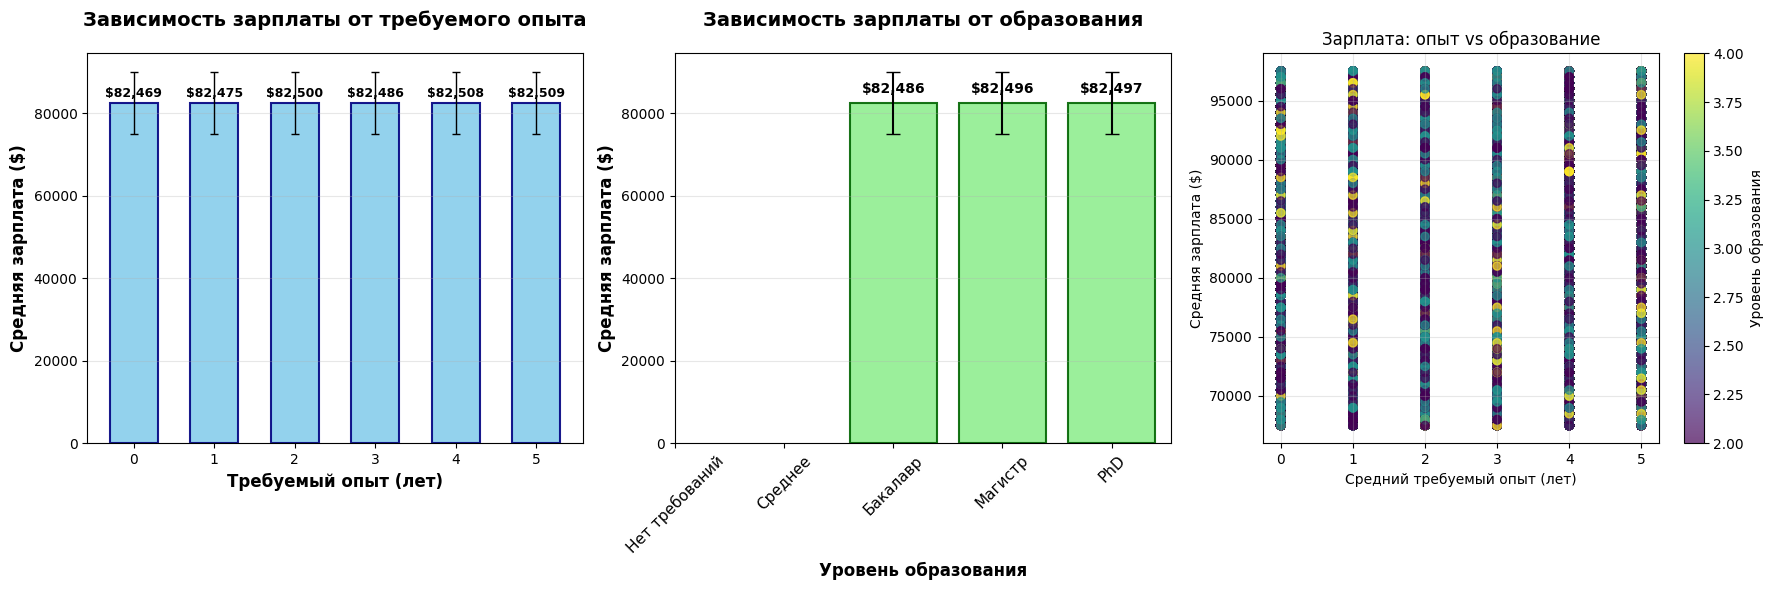

In [11]:
# АНАЛИЗ 1 
print("="*60)
print("АНАЛИЗ 1")
print("="*60)

data_an1 = data.copy()
# Создаем числовой показатель для уровня образования
def education_to_numeric(qualification):
    """
    Преобразует квалификацию в числовой показатель.
    Шкала: 0 - без требований, 1 - среднее, 2 - бакалавр, 3 - магистр, 4 - PhD
    """
    if pd.isna(qualification):
        return 0
    
    qual = str(qualification).lower()
    
    if any(word in qual for word in ['phd', 'doctorate', 'doctoral']):
        return 4
    elif any(word in qual for word in ['master', 'mba', 'msc', 'mca', 'ma', 'm.tech', 'm.eng', 'm.com']):
        return 3
    elif any(word in qual for word in ['bachelor', 'bca', 'bsc', 'bba', 'ba', 'b.com', 'b.tech', 'b.eng', 'undergraduate']):
        return 2
    elif any(word in qual for word in ['high school', 'secondary', 'diploma', 'associate']):
        return 1
    else:
        #print(qual)
        return 0  # для других случаев

# Применяем функцию

data_an1.drop(['latitude', 'longitude', 'Company Size'], axis=1)
data_an1['Education_Score'] = data_an1['Qualifications'].apply(education_to_numeric)

print("ПОДГОТОВКА ДАННЫХ ДЛЯ АНАЛИЗА\n\n")
print(f"Размер выборки для анализа: {len(data_an1)} записей")
print(f"\nРаспределение уровней образования:")
print(data_an1['Education_Score'].value_counts().sort_index())
print("\nОписательная статистика:")
print(data_an1.describe())

# Создаем графики для визуального анализа
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


# 1. Столбчатая диаграмма зарплаты по опыту
exp_salary_ungrouped = data_an1.groupby('Experience_Min')['Salary_Avg'].agg(['mean', 'std', 'count']).reset_index()
exp_salary_ungrouped = exp_salary_ungrouped.sort_values('Experience_Min')

# Создаем столбчатую диаграмму
bars = axes[0].bar(exp_salary_ungrouped['Experience_Min'], 
                  exp_salary_ungrouped['mean'], 
                  width=0.6, color='skyblue', 
                  edgecolor='navy', linewidth=1.5, alpha=0.9,
                  yerr=exp_salary_ungrouped['std'], capsize=3, error_kw={'elinewidth': 1})

axes[0].set_xlabel('Требуемый опыт (лет)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Средняя зарплата ($)', fontsize=12, fontweight='bold')
axes[0].set_title('Зависимость зарплаты от требуемого опыта', fontsize=14, fontweight='bold', pad=20)
axes[0].grid(True, alpha=0.3, axis='y')

min_exp = int(exp_salary_ungrouped['Experience_Min'].min())
max_exp = int(exp_salary_ungrouped['Experience_Min'].max())
axes[0].set_xticks(range(min_exp, max_exp + 1))
axes[0].set_xticklabels(range(min_exp, max_exp + 1))

# Добавляем значения над столбцами (только если есть данные)
for i, bar in enumerate(bars):
    height = bar.get_height()
    if not np.isnan(height) and height > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                    f'${height:,.0f}', ha='center', va='bottom', 
                    fontsize=9, fontweight='bold')

# 2. Зарплата от уровня образования
education_labels = {0: 'Нет требований', 1: 'Среднее', 2: 'Бакалавр', 3: 'Магистр', 4: 'PhD'}
education_mapping = data_an1.copy()
education_mapping['Education_Label'] = education_mapping['Education_Score'].map(education_labels)

# Группируем по уровню образования и считаем среднюю зарплату
edu_salary = education_mapping.groupby('Education_Label')['Salary_Avg'].agg(['mean', 'std', 'count'])
edu_order = ['Нет требований', 'Среднее', 'Бакалавр', 'Магистр', 'PhD']
edu_salary = edu_salary.reindex(edu_order)

# Строим столбчатую диаграмму с тем же стилем
bars2 = axes[1].bar(range(len(edu_salary)), edu_salary['mean'], 
                   yerr=edu_salary['std'], capsize=5, color='lightgreen', 
                   edgecolor='darkgreen', linewidth=1.5, alpha=0.9)
axes[1].set_xlabel('Уровень образования', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Средняя зарплата ($)', fontsize=12, fontweight='bold')
axes[1].set_title('Зависимость зарплаты от образования', fontsize=14, fontweight='bold', pad=20)
axes[1].set_xticks(range(len(edu_salary)))
axes[1].set_xticklabels(edu_salary.index, rotation=45, fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

# Добавляем значения над столбцами
for i, bar in enumerate(bars2):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                f'${height:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Совместное влияние опыта и образования
scatter = axes[2].scatter(data_an1['Experience_Min'], 
                            data_an1['Salary_Avg'], 
                            c=data_an1['Education_Score'], 
                            cmap='viridis', alpha=0.7)
axes[2].set_xlabel('Средний требуемый опыт (лет)')
axes[2].set_ylabel('Средняя зарплата ($)')
axes[2].set_title('Зарплата: опыт vs образование')
plt.colorbar(scatter, ax=axes[2], label='Уровень образования')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Вывод:  на  основе  проведённого  анализа  гипотеза подтвердилась,  имея двухлетний опыт работы, можно претендовать на зарплату большую, чем имея высшее образование. 

Так, средняя зарплата для вакансий с требуемым двухлетним опытом 
работы: $82,500 

Средняя зарплата для соискателя с образованием PhD: $82,497 

#### Гипотеза  2  – Вакансии,  требующие  узкоспециализированных технических  навыков,  предлагают  более  высокую  зарплату,  но  при добавлении управленческих навыков относительная премия снижается. 

Для  этого  составим  гистограммы,  которые  будут  отображать 
распределение  между  средней  зарплатой  для  различных  уровней 
специальности: 

1) High_Tech_Only – только технические навыки (>2) 
2) High_Tech_with_Mgmt – технические навыки (>2) с примесью менеджмента (>= 1) 
3) Mid_Tech_Only – технические навыки (1-2) 
4) Mid_Tech_with_Mgmt – технические навыки (1-2) с примесью менеджмента (>= 1) 
5) Mgmt_Only – только навыки менеджмента (больше 1)

ГИПОТЕЗА 2: Вакансии с узкоспециализированными техническими навыками предлагают более
высокую зарплату, но при добавлении управленческих навыков относительная премия снижается

РАСПРЕДЕЛЕНИЕ ВАКАНСИЙ ПО ТИПАМ НАВЫКОВ:
  Mgmt_Only: 336989 вакансий (20.9%)
  High_Tech_Only: 326040 вакансий (20.2%)
  Mid_Tech_with_Mgmt: 301764 вакансий (18.7%)
  Mid_Tech_Only: 247470 вакансий (15.3%)
  Other: 240101 вакансий (14.9%)
  High_Tech_with_Mgmt: 163576 вакансий (10.1%)

СРЕДНИЕ ЗАРПЛАТЫ ПО КАТЕГОРИЯМ НАВЫКОВ:
                        mean   median     std   count
Skill_Category                                       
Mid_Tech_Only        82509.0  82500.0  7524.0  247470
High_Tech_with_Mgmt  82507.0  82500.0  7515.0  163576
High_Tech_Only       82490.0  82500.0  7538.0  326040
Other                82487.0  82500.0  7534.0  240101
Mgmt_Only            82482.0  82500.0  7528.0  336989
Mid_Tech_with_Mgmt   82482.0  82500.0  7524.0  301764

СТАТИСТИЧЕСКИЙ АНАЛИЗ:

Сравнение High_Tech_Only vs High_Tech_

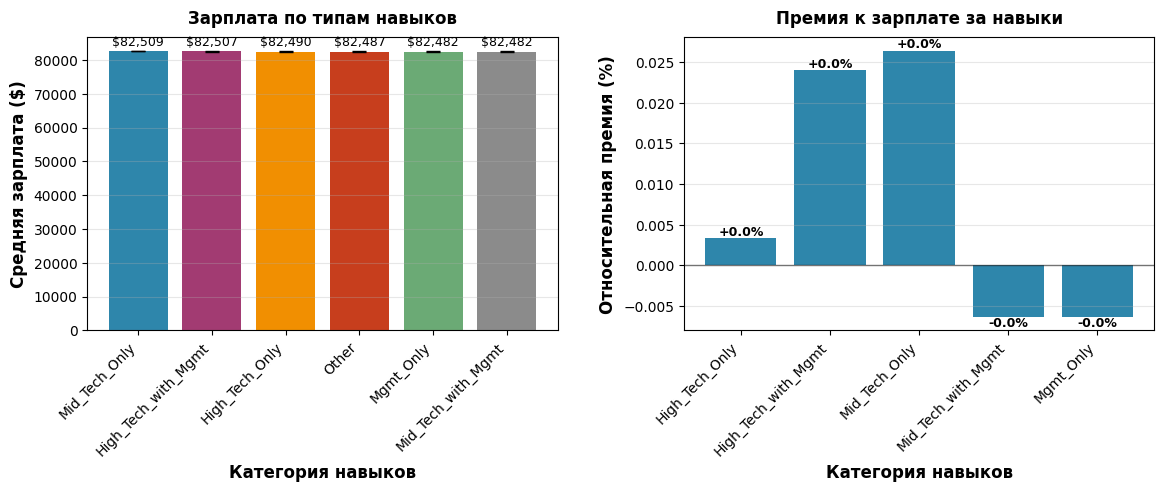

In [21]:
# ВТОРАЯ ГИПОТЕЗА: Влияние специализированных технических и управленческих навыков на зарплату
print("="*80)
print("ГИПОТЕЗА 2: Вакансии с узкоспециализированными техническими навыками предлагают более")
print("высокую зарплату, но при добавлении управленческих навыков относительная премия снижается")
print("="*80)

# Создаем копию данных для анализа
data_an2 = data.copy()

# 1. Определяем списки навыков
# Технические (узкоспециализированные) навыки
tech_skills_keywords = [
    # Программирование
    'python', 'java', 'javascript', 'c++', 'c#', 'ruby', 'php', 'go', 'rust', 'scala', 'kotlin', 'programming',
    # Веб-разработка
    'react', 'angular', 'vue', 'node.js', 'django', 'flask', 'spring', 'laravel', 'backend', 'web', 'html',
    # Базы данных
    'sql', 'nosql', 'mongodb', 'postgresql', 'mysql', 'redis', 'oracle',
    # DevOps и инфраструктура
    'docker', 'kubernetes', 'aws', 'azure', 'gcp', 'terraform', 'ansible', 'jenkins',
    # Data Science и ML
    'machine learning', 'deep learning', 'tensorflow', 'pytorch', 'data science', 'big data', 'data analysis',
    # Специализированные технологии
    'blockchain', 'cybersecurity', 'embedded', 'iot', 'ar/vr', 'computer vision',
    # Другие технические
    'devops', 'sre', 'qa', 'testing', 'automation', 'cad', 'protocols', 'firewall', 'autocad', 'engineering',
    'data', 'troubleshooting', 'database', 'hardware', 'software', 'operating system'
]

# Управленческие навыки
management_skills_keywords = [
    'management', 'leadership', 'team lead', 'project management', 'agile', 'scrum',
    'stakeholder', 'strategic', 'budget', 'planning', 'mentoring', 'coaching',
    'people management', 'resource management', 'risk management', 'product management',
    'program management', 'portfolio management', 'kanban'
]

# 2. Функция для поиска навыков в тексте
def find_skills(text, skill_list):
    """Находит навыки из списка в тексте"""
    if pd.isna(text):
        return 0
    
    text = str(text).lower()
    found_skills = []
    
    for skill in skill_list:
        if skill in text:
            found_skills.append(skill)
    
    return len(found_skills)

# 3. Создаем новые колонки
# Находим навыки в столбцах Skills и Responsibilities
data_an2['Tech_Skills_Count'] = data_an2['skills'].apply(
    lambda x: find_skills(x, tech_skills_keywords)
)
data_an2['Mgmt_Skills_Count'] = data_an2['skills'].apply(
    lambda x: find_skills(x, management_skills_keywords)
)

# Также проверяем Responsibilities
data_an2['Tech_in_Resp'] = data_an2['Responsibilities'].apply(
    lambda x: find_skills(x, tech_skills_keywords)
)
data_an2['Mgmt_in_Resp'] = data_an2['Responsibilities'].apply(
    lambda x: find_skills(x, management_skills_keywords)
)

# Суммируем навыки из обоих источников
data_an2['Total_Tech_Skills'] = data_an2['Tech_Skills_Count'] + data_an2['Tech_in_Resp']
data_an2['Total_Mgmt_Skills'] = data_an2['Mgmt_Skills_Count'] + data_an2['Mgmt_in_Resp']

# 4. Классифицируем вакансии по типам навыков
def classify_skills(row):
    tech = row['Total_Tech_Skills']
    mgmt = row['Total_Mgmt_Skills']
    
    if tech > 2 and mgmt == 0:
        return 'High_Tech_Only'
    elif tech > 2 and mgmt >= 1:
        return 'High_Tech_with_Mgmt'
    elif 1 <= tech <= 2 and mgmt == 0:
        return 'Mid_Tech_Only'
    elif 1 <= tech <= 2 and mgmt >= 1:
        return 'Mid_Tech_with_Mgmt'
    elif tech == 0 and mgmt >= 1:
        return 'Mgmt_Only'
    else:
        return 'Other'

data_an2['Skill_Category'] = data_an2.apply(classify_skills, axis=1)

# 5. Анализ зарплат по категориям навыков
print("\nРАСПРЕДЕЛЕНИЕ ВАКАНСИЙ ПО ТИПАМ НАВЫКОВ:")
category_counts = data_an2['Skill_Category'].value_counts()
for category, count in category_counts.items():
    percentage = (count / len(data_an2)) * 100
    print(f"  {category}: {count} вакансий ({percentage:.1f}%)")

print("\nСРЕДНИЕ ЗАРПЛАТЫ ПО КАТЕГОРИЯМ НАВЫКОВ:")
salary_by_category = data_an2.groupby('Skill_Category')['Salary_Avg'].agg([
    'mean', 'median', 'std', 'count'
]).round(0)

print(salary_by_category.sort_values('mean', ascending=False))

# 6. Статистический анализ
print("\nСТАТИСТИЧЕСКИЙ АНАЛИЗ:")

# Сравниваем High_Tech_Only и High_Tech_with_Mgmt
group_tech_only = data_an2[data_an2['Skill_Category'] == 'High_Tech_Only']['Salary_Avg']
group_tech_mgmt = data_an2[data_an2['Skill_Category'] == 'High_Tech_with_Mgmt']['Salary_Avg']

if len(group_tech_only) > 10 and len(group_tech_mgmt) > 10:
    
    print(f"\nСравнение High_Tech_Only vs High_Tech_with_Mgmt:")
    print(f"Средняя зарплата (только тех): ${group_tech_only.mean():,.0f}")
    print(f"Средняя зарплата (тех + менеджмент): ${group_tech_mgmt.mean():,.0f}")
    print(f"Разница: ${group_tech_mgmt.mean() - group_tech_only.mean():,.0f}")
    
    # Расчет относительной премии
    base_salary = data_an2[data_an2['Skill_Category'] == 'Other']['Salary_Avg'].mean()
    if not pd.isna(base_salary):
        premium_tech_only = (group_tech_only.mean() - base_salary) / base_salary * 100
        premium_tech_mgmt = (group_tech_mgmt.mean() - base_salary) / base_salary * 100
        
        print(f"\nОТНОСИТЕЛЬНАЯ ПРЕМИЯ (относительно 'Other' категории):")
        print(f"Базовая зарплата (Other): ${base_salary:,.0f}")
        print(f"Премия за высокие технавыки: +{premium_tech_only:.1f}%")
        print(f"Премия за технавыки + менеджмент: +{premium_tech_mgmt:.1f}%")
        print(f"Разница в премиях: {premium_tech_only - premium_tech_mgmt:.1f}%")


%matplotlib inline
plt.rcParams['figure.figsize'] = [14, 7] 

# 7. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# График 1: Распределение зарплат по категориям навыков
categories = salary_by_category.sort_values('mean', ascending=False).index
means = salary_by_category.loc[categories, 'mean']
errors = salary_by_category.loc[categories, 'std'] / np.sqrt(salary_by_category.loc[categories, 'count'])

bars = axes[0].bar(range(len(categories)), means, yerr=errors, capsize=5,
                  color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6BAA75', '#8B8B8B'])
axes[0].set_xlabel('Категория навыков', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Средняя зарплата ($)', fontsize=12, fontweight='bold')
axes[0].set_title('Зарплата по типам навыков', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xticks(range(len(categories)))
axes[0].set_xticklabels(categories, rotation=25, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

# Добавляем значения
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'${height:,.0f}', ha='center', va='bottom', fontsize=9)


# График 3: Относительная премия
if 'base_salary' in locals() and not pd.isna(base_salary):
    categories_for_premium = ['High_Tech_Only', 'High_Tech_with_Mgmt', 'Mid_Tech_Only',
                             'Mid_Tech_with_Mgmt', 'Mgmt_Only']
    premiums = []
    
    for cat in categories_for_premium:
        if cat in salary_by_category.index:
            cat_salary = salary_by_category.loc[cat, 'mean']
            premium = (cat_salary - base_salary) / base_salary * 100
            premiums.append(premium)
        else:
            premiums.append(0)
    
    axes[1].bar(range(len(categories_for_premium)), premiums, color='#2E86AB')
    axes[1].set_xlabel('Категория навыков', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Относительная премия (%)', fontsize=12, fontweight='bold')
    axes[1].set_title('Премия к зарплате за навыки', fontsize=12, fontweight='bold', pad=10)
    axes[1].set_xticks(range(len(categories_for_premium)))
    axes[1].set_xticklabels(categories_for_premium, rotation=25, ha='right')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Добавляем линию нуля
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    # Добавляем значения
    for i, premium in enumerate(premiums):
        axes[1].text(i, premium, 
                    f'{premium:+.1f}%', 
                    ha='center', 
                    va='bottom' if premium >= 0 else 'top',
                    fontsize=9, fontweight='bold')

#plt.tight_layout(pad=2.0, h_pad=3.0, w_pad=3.0, rect=[0, 0.03, 1, 0.95])

plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout(rect=[0, 0.05, 1, 0.93], pad=2.0, w_pad=3.0)
#plt.subplots_adjust(left=0.1, right=0.95, top=0.88, bottom=0.25, wspace=0.3)
plt.show()

Вывод: результаты анализа показывают, что зарплаты менеджеров в среднем ниже,  чем  у  технических  специалистов,  но  при  этом  для высококвалифицированных  технических  специалистов  добавление мененджерских  обязанностей  ведёт  к  повышению  зарплаты,  а  вот  для специалистов  среднего  звена  менеджерские  качества  ведут  к  уменьшению зарплаты.  Таким  образом  наша  гипотеза  подтвердилась  частично, относительная  премия  снижается  для  средних  специалистов,  а  вот  у профессионалов  премия  повышается  при  добавлении правленческих 
навыков.

#### Гипотеза 3 –  В больших компаниях на аналогичных позициях платят в среднем больше, чем в малых. 

Для этого составим гистограммы, которые будут отображать зарплаты в разных категориях компаний (малые –  <  20000  чел, средние –  от 20000 до 50000, большие - >50000)

ГИПОТЕЗА: В больших компаниях на аналогичных позициях (Role) платят
в среднем больше, чем в маленьких компаниях
КЛАССИФИКАЦИЯ КОМПАНИЙ ПО РАЗМЕРУ:
Минимальное число сотрудников в компании: 12646
Минимальное число сотрудников в компании: 134834

Распределение компаний по категориям:
  Large: 1120822 компаний (69.4%)
  Medium: 397811 компаний (24.6%)
  Small: 97307 компаний (6.0%)

ОБЩИЙ АНАЛИЗ ЗАРПЛАТ ПО РАЗМЕРУ КОМПАНИЙ:
                    count     mean   median     std      min      max
Company_Category                                                     
Large             1120822  82494.0  82500.0  7527.0  67500.0  97500.0
Small               97307  82490.0  82500.0  7524.0  67500.0  97500.0
Medium             397811  82483.0  82500.0  7533.0  67500.0  97500.0

СРАВНЕНИЕ В ЦЕЛОМ:
Средняя зарплата в больших компаниях: $82,494
Средняя зарплата в маленьких компаниях: $82,490
Разница: $4
В целом большие компании платят больше

АНАЛИЗ ПО КОНКРЕТНЫМ ПОЗИЦИЯМ (ROLE)
Анализируем 20 самых ч

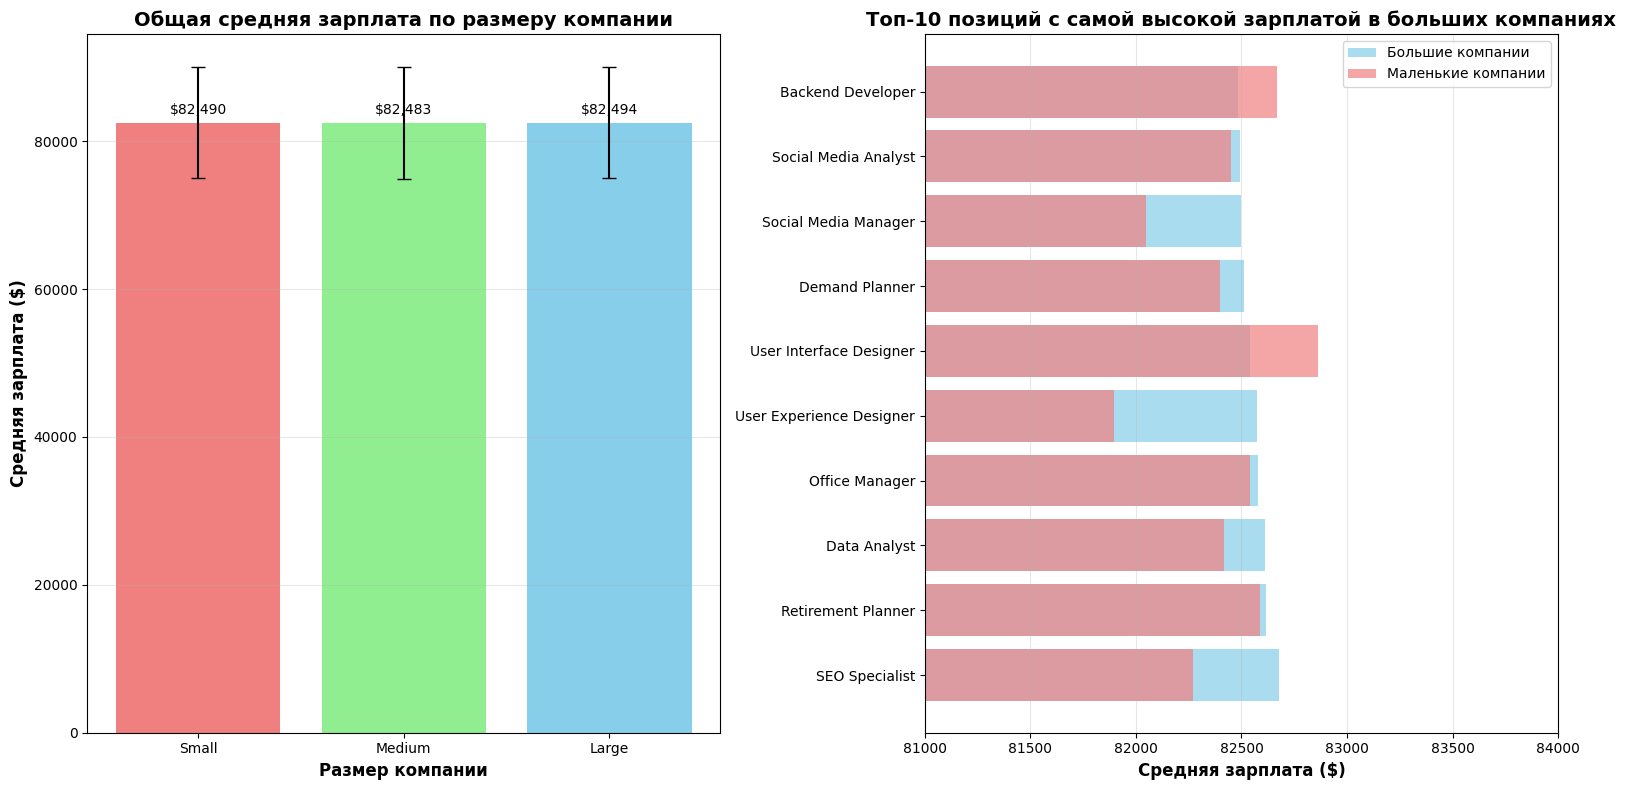

In [13]:
# ГИПОТЕЗА: В больших компаниях на аналогичных позициях платят в среднем больше, чем в маленьких
print("="*80)
print("ГИПОТЕЗА: В больших компаниях на аналогичных позициях (Role) платят")
print("в среднем больше, чем в маленьких компаниях")
print("="*80)

# Создаем копию данных для анализа
data_an3 = data.copy()

# 1. Определяем категории компаний (большие vs маленькие)
print("КЛАССИФИКАЦИЯ КОМПАНИЙ ПО РАЗМЕРУ:")

print(f"Минимальное число сотрудников в компании: {data_an3['Company Size'].min()}")
print(f"Минимальное число сотрудников в компании: {data_an3['Company Size'].max()}")

if 'Company Size' in data_an3.columns:
    def classify_company_size(size):
        if size <= 20000: return "Small" 
        if size <= 50000: return "Medium" 
        if size > 50000: return "Large" 

    data_an3['Company_Category'] = data_an3['Company Size'].apply(classify_company_size)

# Статистика по категориям
category_counts = data_an3['Company_Category'].value_counts()
print("\nРаспределение компаний по категориям:")
for category, count in category_counts.items():
    percentage = (count / len(data_an3)) * 100
    print(f"  {category}: {count} компаний ({percentage:.1f}%)")




# 2. Анализ зарплат по категориям компаний в целом
print("\nОБЩИЙ АНАЛИЗ ЗАРПЛАТ ПО РАЗМЕРУ КОМПАНИЙ:")

if 'Company_Category' in data_an3.columns:
    # Общая статистика зарплат по категориям компаний
    overall_stats = data_an3.groupby('Company_Category')['Salary_Avg'].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(0)
    
    print(overall_stats.sort_values('mean', ascending=False).to_string())
    
    # Проверяем гипотезу в целом
    if 'Large' in overall_stats.index and 'Small' in overall_stats.index:
        large_mean = overall_stats.loc['Large', 'mean']
        small_mean = overall_stats.loc['Small', 'mean']
        diff = large_mean - small_mean
        
        print(f"\nСРАВНЕНИЕ В ЦЕЛОМ:")
        print(f"Средняя зарплата в больших компаниях: ${large_mean:,.0f}")
        print(f"Средняя зарплата в маленьких компаниях: ${small_mean:,.0f}")
        print(f"Разница: ${diff:,.0f}")
        
        if diff > 0:
            print(f"В целом большие компании платят больше")
        else:
            print(f"В целом маленькие компании платят больше")

# 3. Анализ по конкретным позициям (Role)
print("\n" + "="*80)
print("АНАЛИЗ ПО КОНКРЕТНЫМ ПОЗИЦИЯМ (ROLE)")
print("="*80)

if 'Role' in data_an3.columns and 'Company_Category' in data_an3.columns:
    # Находим самые частые позиции (топ-20)
    top_roles = data_an3['Role'].value_counts().head(20)
    
    print(f"Анализируем {len(top_roles)} самых частых позиций:")
    
    # Создаем список для хранения результатов
    role_comparison_results = []
    
    # Анализируем каждую позицию
    for role_name, role_count in top_roles.items():
        # Фильтруем данные по позиции
        role_data = data_an3[data_an3['Role'] == role_name]
        
        # Проверяем, есть ли данные для больших и маленьких компаний
        if 'Large' in role_data['Company_Category'].values and 'Small' in role_data['Company_Category'].values:
            # Группируем по категории компании
            role_stats = role_data.groupby('Company_Category')['Salary_Avg'].agg(['mean', 'count']).round(0)
            
            # Проверяем, что есть достаточно данных
            if role_stats.loc['Large', 'count'] >= 5 and role_stats.loc['Small', 'count'] >= 5:
                large_salary = role_stats.loc['Large', 'mean']
                small_salary = role_stats.loc['Small', 'mean']
                
                # Вычисляем разницу
                if small_salary > 0:  # Чтобы избежать деления на ноль
                    diff = large_salary - small_salary
                    diff_percentage = (diff / small_salary) * 100
                    
                    # Добавляем в результаты
                    role_comparison_results.append({
                        'Role': role_name,
                        'Large_Companies': large_salary,
                        'Small_Companies': small_salary,
                        'Difference_Amount': diff,
                        'Difference_Percentage': diff_percentage,
                        'Large_Count': role_stats.loc['Large', 'count'],
                        'Small_Count': role_stats.loc['Small', 'count']
                    })
    

    comparison_df = pd.DataFrame(role_comparison_results)
        
    # Сортируем по абсолютной разнице
    comparison_df['Abs_Difference'] = comparison_df['Difference_Amount'].abs()
    comparison_df = comparison_df.sort_values('Abs_Difference', ascending=False)
    
    print(f"\nРЕЗУЛЬТАТЫ СРАВНЕНИЯ ПО ПОЗИЦИЯМ:")
    print(f"Проанализировано {len(comparison_df)} позиций с достаточным количеством данных")
    
    # Статистика по гипотезе
    positive_diff = comparison_df[comparison_df['Difference_Amount'] > 0]
    negative_diff = comparison_df[comparison_df['Difference_Amount'] < 0]
        
    print(f"\nСТАТИСТИКА ГИПОТЕЗЫ:")
    print(f"Позиций, где большие компании платят больше: {len(positive_diff)} ({len(positive_diff)/len(comparison_df)*100:.1f}%)")
    print(f"Позиций, где маленькие компании платят больше: {len(negative_diff)} ({len(negative_diff)/len(comparison_df)*100:.1f}%)")
    print(f"Позиций с одинаковой зарплатой: {len(comparison_df) - len(positive_diff) - len(negative_diff)}")
        
     # Средняя разница по всем позициям
    avg_diff_percentage = comparison_df['Difference_Percentage'].mean()
    median_diff_amount = comparison_df['Difference_Amount'].median()
    
    print(f"\nСРЕДНИЕ ПОКАЗАТЕЛИ:")
    print(f"Средняя разница в процентах: {avg_diff_percentage:+.1f}%")
    print(f"Медианная разница в деньгах: ${median_diff_amount:,.0f}")
    
    # Проверка гипотезы
    if len(positive_diff) > len(negative_diff):
        print(f"\nГИПОТЕЗА ПОДТВЕРЖДАЕТСЯ:")
        print(f"   В {len(positive_diff)} из {len(comparison_df)} позиций большие компании платят больше")
        print(f"   Средняя премия в больших компаниях: {avg_diff_percentage:+.1f}%")
    else:
        print(f"\nГИПОТЕЗА НЕ ПОДТВЕРЖДАЕТСЯ:")
        print(f"   В {len(negative_diff)} из {len(comparison_df)} позиций маленькие компании платят больше")
        print(f"   В среднем маленькие компании платят на {abs(avg_diff_percentage):.1f}% больше")
    
    # Показываем топ-10 позиций с самой большой разницей
    print(f"\nТОП-10 ПОЗИЦИЙ С НАИБОЛЬШЕЙ РАЗНИЦЕЙ В ЗАРПЛАТЕ:")
    top_diffs = comparison_df.head(10).copy()
    
    # Форматируем вывод
    for i, row in top_diffs.iterrows():
        if row['Difference_Amount'] > 0:
            arrow = "↑"  # Большие компании платят больше
            diff_text = f"+${row['Difference_Amount']:,.0f} ({row['Difference_Percentage']:+.1f}%)"
        else:
            arrow = "↓"  # Маленькие компании платят больше
            diff_text = f"-${abs(row['Difference_Amount']):,.0f} ({row['Difference_Percentage']:.1f}%)"
        
        print(f"{arrow} {row['Role'][:40]:40} | "
              f"Большие: ${row['Large_Companies']:,.0f} | "
              f"Маленькие: ${row['Small_Companies']:,.0f} | "
              f"Разница: {diff_text}")
    
# 4. Визуализация результатов
    print("\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # График 1: Распределение зарплат по категориям компаний
    categories = ['Small', 'Medium', 'Large']
    category_means = []
    category_stds = []
    
    for cat in categories:
        if cat in data_an3['Company_Category'].unique():
            cat_data = data_an3[data_an3['Company_Category'] == cat]['Salary_Avg']
            category_means.append(cat_data.mean())
            category_stds.append(cat_data.std())
        else:
            category_means.append(0)
            category_stds.append(0)
    
    bars1 = axes[0].bar(range(len(categories)), category_means, 
                          yerr=category_stds, capsize=5, 
                          color=['lightcoral', 'lightgreen', 'skyblue'])
    axes[0].set_xlabel('Размер компании', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Средняя зарплата ($)', fontsize=12, fontweight='bold')
    axes[0].set_title('Общая средняя зарплата по размеру компании', 
                        fontsize=14, fontweight='bold')
    axes[0].set_xticks(range(len(categories)))
    axes[0].set_xticklabels(categories)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                      f'${height:,.0f}', ha='center', va='bottom', fontsize=10)
    
    # График 2: Топ-10 позиций с наибольшей зарплатой в больших компаниях
    top_10_large = comparison_df.sort_values('Large_Companies', ascending=False).head(10)
    
    y_pos = range(len(top_10_large))
    axes[1].barh(y_pos, top_10_large['Large_Companies'], color='skyblue', alpha=0.7, label='Большие компании')
    axes[1].barh(y_pos, top_10_large['Small_Companies'], color='lightcoral', alpha=0.7, label='Маленькие компании')
        
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels([role[:25] + '...' if len(role) > 25 else role 
                                   for role in top_10_large['Role']])
    axes[1].set_xlabel('Средняя зарплата ($)', fontsize=12, fontweight='bold')
    axes[1].set_title('Топ-10 позиций с самой высокой зарплатой в больших компаниях', 
                            fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].set_xlim(81000,84000)
    axes[1].grid(True, alpha=0.3, axis='x')
        
        
    plt.tight_layout()
    plt.show()

else:
    print("Для анализа необходимы колонки 'Role' и 'Company Size'")


Вывод:  Гипотеза в целом подтвердилась, в больших компаниях на 8 из 10 вакансиях  платят  больше,  чем  в  малых,  но,  что  примечательно,  средняя зарплата по всем вакансиям меньше всего в средних компаниях. 

#### Гипотеза 4 –  Зарплатные предложения имеют сезонную зависимость от даты размещения вакансии, при этом пик зарплат приходится на начало года.

Для этого создадим график, на котором отобразим средние зарплаты по месяцам, выделим начало года, а также экстремумы зарплат:

ГИПОТЕЗА 4: Зарплатные предложения имеют сезонную зависимость от даты
размещения вакансии, при этом пик зарплат приходится на начало года
ПОДГОТОВКА ДАННЫХ С ДАТАМИ:
Найдена колонка с датой: 'Job Posting Date'
Диапазон дат: с 2021-09-15 по 2023-09-15
Всего лет: 3
никальные годы: [np.int32(2021), np.int32(2022), np.int32(2023)]

РАСПРЕДЕЛЕНИЕ ВАКАНСИЙ ПО ВРЕМЕНИ:
  • Распределение по годам:
      2021: 238944 вакансий (14.8%)
      2022: 806158 вакансий (49.9%)
      2023: 570838 вакансий (35.3%)
  • Распределение по месяцам:
      Январь: 137277 вакансий (8.5%)
      Февраль: 123198 вакансий (7.6%)
      Март: 137121 вакансий (8.5%)
      Апрель: 132450 вакансий (8.2%)
      Май: 137364 вакансий (8.5%)
      Июнь: 132722 вакансий (8.2%)
      Июль: 137594 вакансий (8.5%)
      Август: 136485 вакансий (8.4%)
      Сентябрь: 134696 вакансий (8.3%)
      Октябрь: 137239 вакансий (8.5%)
      Ноябрь: 132564 вакансий (8.2%)
      Декабрь: 137230 вакансий (8.5%)
  • Распределение по квартала

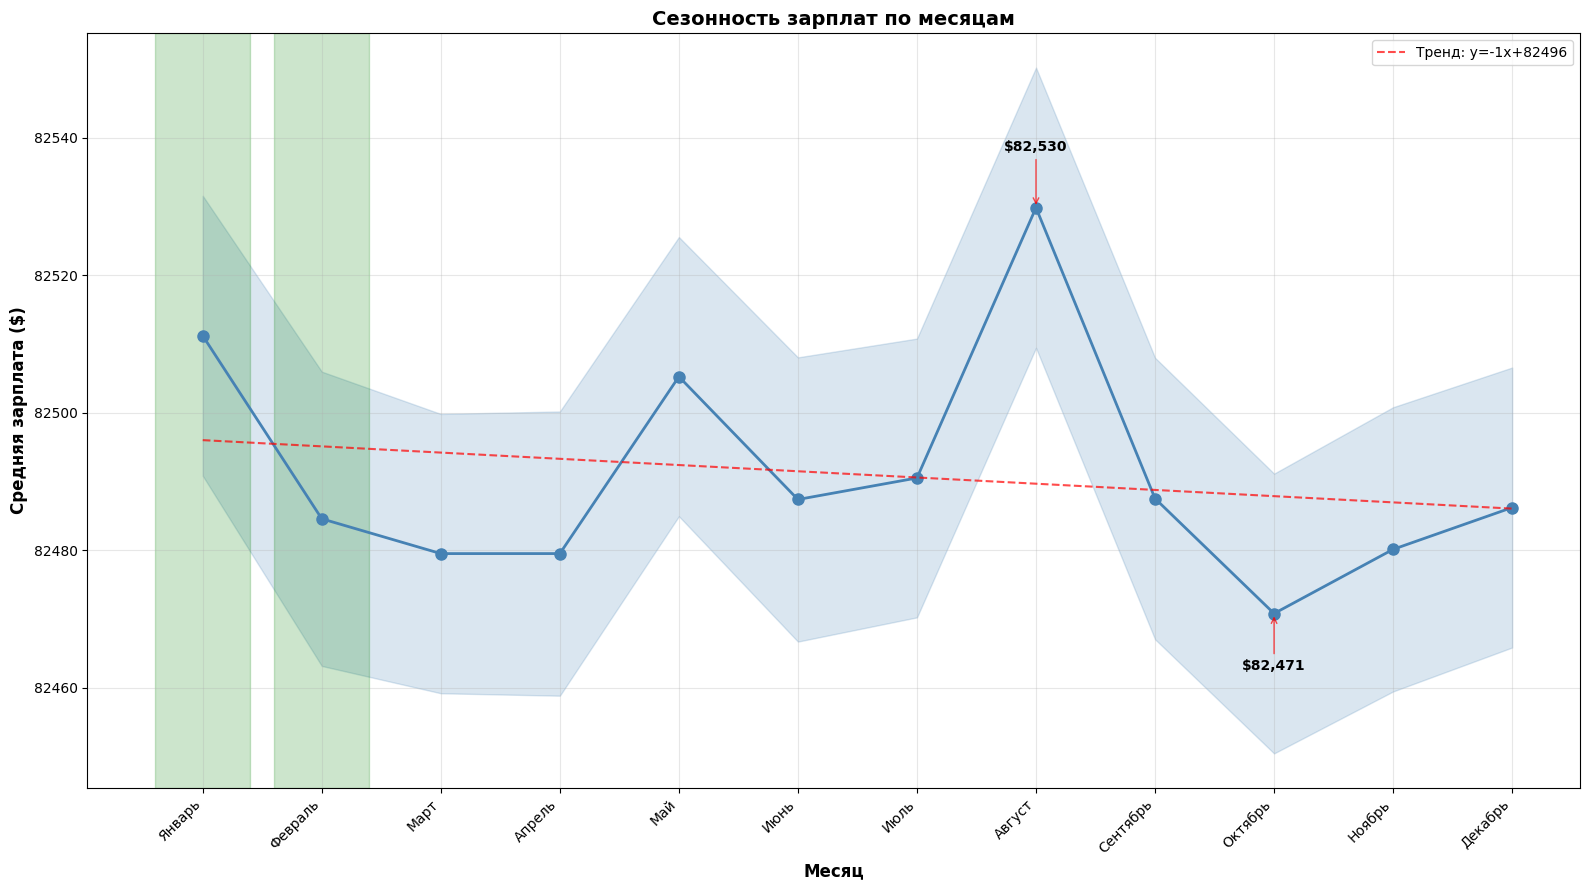

In [25]:
# ГИПОТЕЗА 4: Сезонность зарплатных предложений
print("="*80)
print("ГИПОТЕЗА 4: Зарплатные предложения имеют сезонную зависимость от даты")
print("размещения вакансии, при этом пик зарплат приходится на начало года")
print("="*80)

# Создаем копию данных для анализа
data_an4 = data.copy()

# 1. Подготовка данных с датами
print("ПОДГОТОВКА ДАННЫХ С ДАТАМИ:")

# Проверяем наличие колонки с датой
date_column = None
for col in data_an4.columns:
    if 'date' in col.lower() or 'posting' in col.lower():
        date_column = col
        break

if date_column:
    print(f"Найдена колонка с датой: '{date_column}'")
    
    # Преобразуем в datetime
    try:
        data_an4['Job_Date'] = pd.to_datetime(data_an4[date_column], errors='coerce')
        
        # Извлекаем компоненты даты
        data_an4['Year'] = data_an4['Job_Date'].dt.year
        data_an4['Month'] = data_an4['Job_Date'].dt.month
        data_an4['Quarter'] = data_an4['Job_Date'].dt.quarter
        data_an4['Week'] = data_an4['Job_Date'].dt.isocalendar().week
        data_an4['Day'] = data_an4['Job_Date'].dt.day
        data_an4['DayOfWeek'] = data_an4['Job_Date'].dt.dayofweek  # 0 = понедельник
        data_an4['Is_StartOfYear'] = data_an4['Month'].isin([1, 2])  # Январь-февраль
        data_an4['Is_EndOfYear'] = data_an4['Month'].isin([11, 12])  # Ноябрь-декабрь
        
        # Проверяем диапазон дат
        min_date = data_an4['Job_Date'].min()
        max_date = data_an4['Job_Date'].max()
        print(f"Диапазон дат: с {min_date.date()} по {max_date.date()}")
        print(f"Всего лет: {data_an4['Year'].nunique()}")
        print(f"никальные годы: {sorted(data_an4['Year'].dropna().unique())}")
        
    except Exception as e:
        print(f"Ошибка при обработке даты: {e}")
        date_column = None
else:
    print("Колонка с датой не найдена")
    # Проверим доступные колонки
    print("  Доступные колонки:", [col for col in data_an4.columns if 'date' in col.lower() or 'time' in col.lower()])


# 2. Анализ распределения вакансий по времени
print("\nРАСПРЕДЕЛЕНИЕ ВАКАНСИЙ ПО ВРЕМЕНИ:")

if 'Year' in data_an4.columns:
    # Распределение по годам
    year_counts = data_an4['Year'].value_counts().sort_index()
    print(f"  • Распределение по годам:")
    for year, count in year_counts.items():
        if not pd.isna(year):
            print(f"      {int(year)}: {count} вакансий ({count/len(data_an4)*100:.1f}%)")

if 'Month' in data_an4.columns:
    # Распределение по месяцам
    month_counts = data_an4['Month'].value_counts().sort_index()
    print(f"  • Распределение по месяцам:")
    
    month_names = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь',
                   'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']
    
    for month in range(1, 13):
        count = month_counts.get(month, 0)
        if count > 0:
            print(f"      {month_names[month-1]}: {count} вакансий ({count/len(data_an4)*100:.1f}%)")

if 'Quarter' in data_an4.columns:
    # Распределение по кварталам
    quarter_counts = data_an4['Quarter'].value_counts().sort_index()
    print(f"  • Распределение по кварталам:")
    for q in range(1, 5):
        count = quarter_counts.get(q, 0)
        if count > 0:
            print(f"      Q{q}: {count} вакансий ({count/len(data_an4)*100:.1f}%)")

# 3. Анализ зарплат по месяцам
print("\nАНАЛИЗ ЗАРПЛАТ ПО МЕСЯЦАМ:")

if 'Month' in data_an4.columns and 'Salary_Avg' in data_an4.columns:
    # Группируем по месяцам
    month_stats = data_an4.groupby('Month')['Salary_Avg'].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(0)
    
    # Сортируем по среднему значению
    month_stats_sorted = month_stats.sort_values('mean', ascending=False)
    
    print("Средние зарплаты по месяцам (от самого высокого к самому низкому):")
    for month_num in month_stats_sorted.index:
        month_name = month_names[month_num-1]
        mean_salary = month_stats_sorted.loc[month_num, 'mean']
        count = month_stats_sorted.loc[month_num, 'count']
        print(f"  {month_name:10} (месяц {month_num:2d}): ${mean_salary:,.0f} (n={count})")
    
    # Определяем пиковый месяц
    peak_month_num = month_stats_sorted.index[0]
    peak_month_name = month_names[peak_month_num-1]
    peak_salary = month_stats_sorted.iloc[0]['mean']
    
    # Определяем самый низкий месяц
    lowest_month_num = month_stats_sorted.index[-1]
    lowest_month_name = month_names[lowest_month_num-1]
    lowest_salary = month_stats_sorted.iloc[-1]['mean']
    
    # Разница между пиком и минимумом
    salary_diff = peak_salary - lowest_salary
    salary_diff_percent = (salary_diff / lowest_salary) * 100
    
    print(f"\nКЛЮЧЕВЫЕ НАХОДКИ:")
    print(f"Пик зарплат: {peak_month_name} (${peak_salary:,.0f})")
    print(f"Минимум зарплат: {lowest_month_name} (${lowest_salary:,.0f})")
    print(f"Разница: ${salary_diff:,.0f} ({salary_diff_percent:+.1f}%)")
    
    # Проверяем, приходится ли пик на начало года (январь-февраль)
    is_peak_at_start = peak_month_num in [1, 2]
    
    if is_peak_at_start:
        print(f"Пик зарплат действительно приходится на начало года ({peak_month_name})")
    else:
        print(f"Пик зарплат НЕ приходится на начало года ({peak_month_name})")
    
    # Проверяем гипотезу о начале года
    start_year_months = [1, 2]
    end_year_months = [11, 12]
    
    start_year_data = data_an4[data_an4['Month'].isin(start_year_months)]['Salary_Avg']
    end_year_data = data_an4[data_an4['Month'].isin(end_year_months)]['Salary_Avg']
    other_months_data = data_an4[~data_an4['Month'].isin(start_year_months + end_year_months)]['Salary_Avg']
    
    if len(start_year_data) > 0 and len(end_year_data) > 0:
        start_mean = start_year_data.mean()
        end_mean = end_year_data.mean()
        
        print(f"\nСРАВНЕНИЕ НАЧАЛА И КОНЦА ГОДА:")
        print(f"Начало года (январь-февраль): ${start_mean:,.0f} (n={len(start_year_data)})")
        print(f"Конец года (ноябрь-декабрь): ${end_mean:,.0f} (n={len(end_year_data)})")
        print(f"Остальные месяцы: ${other_months_data.mean():,.0f} (n={len(other_months_data)})")
        
        diff_start_end = start_mean - end_mean
        if diff_start_end > 0:
            print(f"Разница начало-конец: ${diff_start_end:,.0f} (+{(diff_start_end/end_mean*100):.1f}%)")
        else:
            print(f"Разница начало-конец: ${diff_start_end:,.0f} ({(diff_start_end/end_mean*100):.1f}%)")


# 4. Визуализация результатов
print("\nВИЗУАЛИЗАЦИЯ СЕЗОННОСТИ ЗАРПЛАТ")

fig, axes = plt.subplots(1, 1, figsize=(16, 9))

# График 1: Зарплаты по месяцам (линейный график)
if 'Month' in data_an4.columns:
    # Группируем по месяцам
    monthly_data = data_an4.groupby('Month')['Salary_Avg'].agg(['mean', 'std', 'count']).sort_index()
    
    # Создаем данные для графика
    months = monthly_data.index
    month_labels = [month_names[m-1] for m in months]
    mean_salaries = monthly_data['mean']
    std_errors = monthly_data['std'] / np.sqrt(monthly_data['count'])
    
    axes.plot(range(len(months)), mean_salaries, 
                   marker='o', linewidth=2, markersize=8, color='steelblue')
    axes.fill_between(range(len(months)), 
                           mean_salaries - std_errors, 
                           mean_salaries + std_errors, 
                           alpha=0.2, color='steelblue')
    
    # Добавляем линию тренда
    z = np.polyfit(range(len(months)), mean_salaries, 1)
    p = np.poly1d(z)
    axes.plot(range(len(months)), p(range(len(months))), 
                   "r--", alpha=0.7, label=f'Тренд: y={z[0]:.0f}x+{z[1]:.0f}')
    
    axes.set_xlabel('Месяц', fontsize=12, fontweight='bold')
    axes.set_ylabel('Средняя зарплата ($)', fontsize=12, fontweight='bold')
    axes.set_title('Сезонность зарплат по месяцам', fontsize=14, fontweight='bold')
    axes.set_xticks(range(len(months)))
    axes.set_xticklabels(month_labels, rotation=45, ha='right')
    axes.grid(True, alpha=0.3)
    axes.legend()
    
    # Выделяем начало года (январь-февраль)
    for i, month in enumerate(months):
        if month in [1, 2]:
            axes.axvspan(i-0.4, i+0.4, alpha=0.2, color='green', label='Начало года' if i==0 else "")
    
    # Добавляем аннотации для пиковых месяцев
    for i, (month, salary) in enumerate(zip(months, mean_salaries)):
        if salary == max(mean_salaries) or salary == min(mean_salaries):
            axes.annotate(f'${salary:,.0f}', 
                              xy=(i, salary), 
                              xytext=(i, salary + (salary*0.0001 if salary == max(mean_salaries) else -salary*0.0001)),
                              arrowprops=dict(arrowstyle="->", color='red', alpha=0.7),
                              fontsize=10, fontweight='bold', ha='center')
    # for i, (month, salary) in enumerate(zip(months, mean_salaries)):
    #     if salary == max(mean_salaries):
    #         # Для максимума: текст размещается НАД точкой (va='bottom')
    #         axes.text(i, salary, f'${salary:,.0f}', 
    #                   ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkred')
    #     elif salary == min(mean_salaries):
    #         # Для минимума: текст размещается ПОД точкой (va='top')
    #         axes.text(i, salary, f'${salary:,.0f}', 
    #                   ha='center', va='top', fontsize=10, fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()

Вывод: Наша гипотеза не подтвердилась, пик зарплат приходится на август, хотя в январе зарплаты действительно выше среднего.

#### Корреляционный анализ 

КОРРЕЛЯЦИОННАЯ МАТРИЦА ДАТАСЕТА
ВЫБОР ЧИСЛОВЫХ ПЕРЕМЕННЫХ ДЛЯ АНАЛИЗА:
  • Найдено 6 числовых колонок:
     1. Company Size
     2. Salary_Min
     3. Salary_Max
     4. Salary_Avg
     5. Experience_Min
     6. Experience_Max

ВЫЧИСЛЕНИЕ КОРРЕЛЯЦИОННОЙ МАТРИЦЫ...
  • Размер матрицы: 6x6
  • Метод корреляции: Пирсона (линейная корреляция)

ВИЗУАЛИЗАЦИЯ КОРРЕЛЯЦИОННОЙ МАТРИЦЫ...


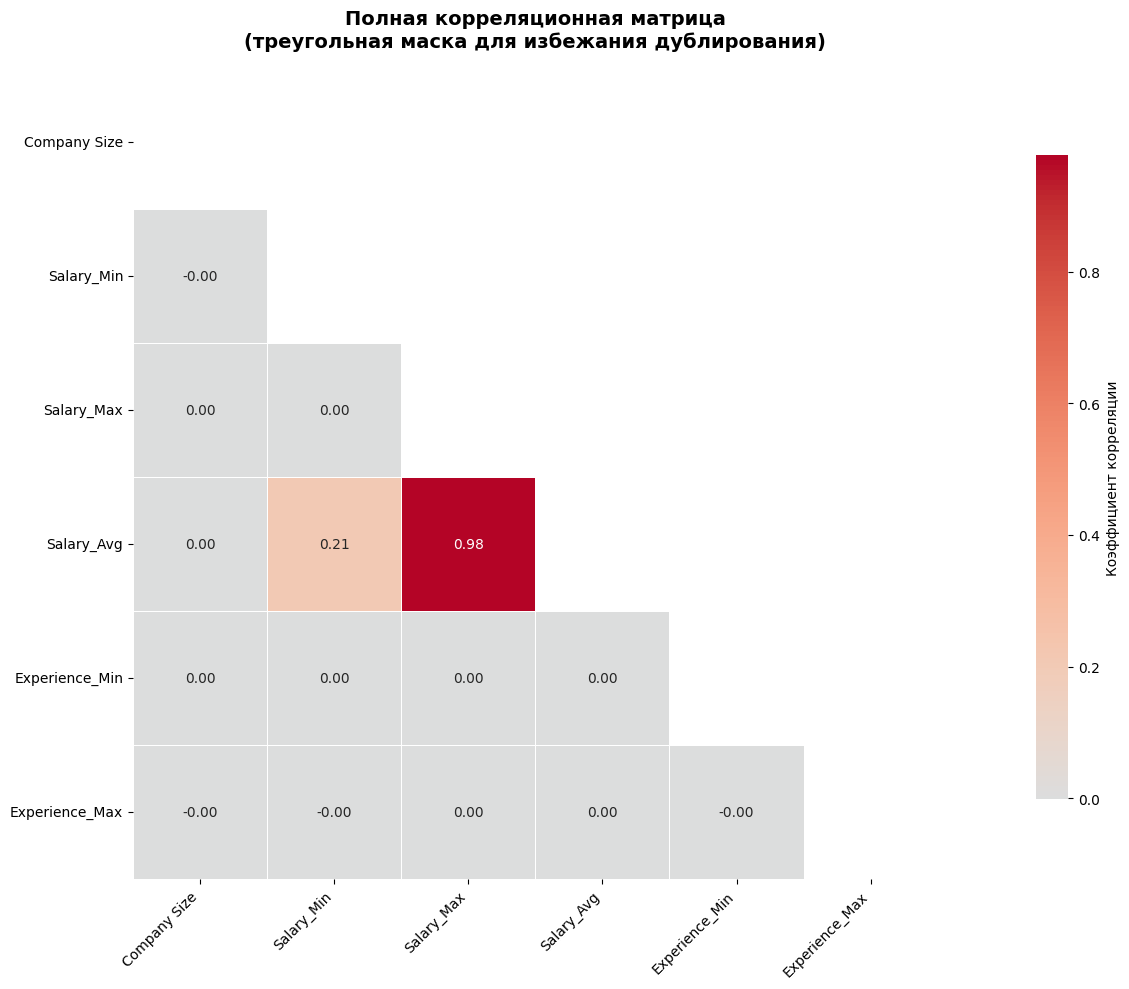

In [15]:
# КОРРЕЛЯЦИОННАЯ МАТРИЦА ДЛЯ ДАТАСЕТА
print("="*80)
print("КОРРЕЛЯЦИОННАЯ МАТРИЦА ДАТАСЕТА")
print("="*80)

# Создаем копию данных для анализа
data_corr = data.copy()

# 1. Выбираем только числовые колонки для корреляционного анализа
print("ВЫБОР ЧИСЛОВЫХ ПЕРЕМЕННЫХ ДЛЯ АНАЛИЗА:")

# Автоматически находим числовые колонки
numeric_cols = data_corr.select_dtypes(include=[np.number]).columns.tolist()

# Исключаем колонки с датами или индексами, если они есть
exclude_keywords = ['job id', 'latitude', 'longitude', 'date']
numeric_cols = [col for col in numeric_cols 
                if not any(keyword in col.lower() for keyword in exclude_keywords)]

print(f"  • Найдено {len(numeric_cols)} числовых колонок:")
for i, col in enumerate(numeric_cols[:20], 1):  # Показываем первые 20
    print(f"    {i:2d}. {col}")

if len(numeric_cols) > 20:
    print(f"    ... и еще {len(numeric_cols) - 20} колонок")

# 2. Строим корреляционную матрицу
print(f"\nВЫЧИСЛЕНИЕ КОРРЕЛЯЦИОННОЙ МАТРИЦЫ...")

# Выбираем только числовые колонки для корреляции
corr_data = data_corr[numeric_cols]

# Вычисляем корреляционную матрицу
correlation_matrix = corr_data.corr()

print(f"  • Размер матрицы: {correlation_matrix.shape[0]}x{correlation_matrix.shape[1]}")
print(f"  • Метод корреляции: Пирсона (линейная корреляция)")

# 3. Визуализация корреляционной матрицы
print(f"\nВИЗУАЛИЗАЦИЯ КОРРЕЛЯЦИОННОЙ МАТРИЦЫ...")

# Создаем фигуру с двумя графиками
fig, ax1 = plt.subplots(1, 1, figsize=(20, 10))

# График 1: Полная тепловая карта корреляций
mask_upper = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Используем diverging палитру для лучшего восприятия
sns.heatmap(correlation_matrix, 
            mask=mask_upper,
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True, 
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"},
            ax=ax1)

ax1.set_title('Полная корреляционная матрица\n(треугольная маска для избежания дублирования)', 
             fontsize=14, fontweight='bold', pad=20)

# Поворачиваем метки осей для лучшей читаемости
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)


plt.tight_layout()
plt.show()

Вывод:  корреляций  не  выявлено,  а  отмеченные  Salary_Avg,  Salary_Max  и Salary_Min легко объясняются тем, что мы изначально делили эти данные по разным  столбцам  и  высчитывали  среднюю  зарплату  для  одной  вакансии исходя из вилки зарплат. Практического значения эта корреляция не несёт. 

### ЗАКЛЮЧЕНИЕ 

В  ходе  научно-исследовательской  работы  был  проведен  анализ  базы данных  «Job  Dataset»,  выявлены  важные  статистические  данные,  которые помогли выявить тенденции размещения вакансий и предложения заработных плат на рынке труда. 

Для  выполнения  данной  работы  было  изучено  новое  программное обеспечение:  «Pandas»,  «Matplotlib»  и  «Seaborn»  на  базе  языка программирования  Python.  Также  использовался  редактор «Visual Studio Code»: в нём происходило написание кода и анализ диаграмм. В ходе работы были  получены  новые  навыки  в  области  анализа  данных  и  произведено знакомство с вышеперечисленными программами. 

Была осуществлена оптимизация использования памяти, агрегирование данных, что в дальнейшем позволило провести необходимые в ходе работы исследования и получить ценные знания в предметной области.